In [1]:
import os, json, random, pickle
from typing import List, Dict, Any

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import cm
import numpy as np

from shapely.geometry import (
    Polygon, MultiPolygon, LineString, MultiLineString, Point, GeometryCollection
)
from shapely.ops import unary_union
from shapely.geometry import mapping as shp_mapping, shape

import resplan_utils as R  

# ---- paths (use your actual pkl name) ----
DATA_PKL     = "ResPlan.pkl"
OUT_JSON_DIR = "resplan_json"
OUT_PLOT_DIR = "resplan_plot"

os.makedirs(OUT_JSON_DIR, exist_ok=True)
os.makedirs(OUT_PLOT_DIR,  exist_ok=True)

# ---- categories ----
ROOM_KEYS  = ["bedroom","bathroom","kitchen","living","balcony","storage","stair","veranda","parking"]
STRUCT_KEYS = ["interior_wall","exterior_wall","door","window","front_door"]
GEOM_LAYERS = ["inner","garden","land","pool"]
META_KEYS   = ["id","unitType","area","net_area","wall_depth"]

# ---- colors ----
ROOM_COLORS = {
    "living":   "#d9d9d9",
    "bedroom":  "#66c2a5",
    "bathroom": "#fc8d62",
    "kitchen":  "#8da0cb",
    "balcony":  "#b3b3b3",
    "storage":  "#cccccc",
    "stair":    "#aaaaaa",
    "veranda":  "#bbbbbb",
    "parking":  "#dddddd",
}
STRUCT_COLORS = {
    "interior_wall": "#445DFF",  
    "exterior_wall": "#FFD344",  
    "door":          "#e78ac3",
    "window":        "#a6d854",
    "front_door":    "#a63603",
}

In [2]:
def label_geom_with_box(ax, geom, text,
                        fontsize=8,
                        face="#FFFFFF", edge="#000000",
                        alpha=0.85, pad=0.25, lw=0.6,
                        z=10):
    p = geom.representative_point()
    ax.text(
        p.x, p.y, text,
        fontsize=fontsize, ha="center", va="center",
        zorder=z,
        bbox=dict(boxstyle=f"square,pad={pad}",
                  facecolor=face, edgecolor=edge,
                  linewidth=lw, alpha=alpha)
    )

def geojsonify(geom):
    if geom is None:
        return {"type":"GeometryCollection","geometries":[]}
    if isinstance(geom, (Polygon, MultiPolygon, LineString, MultiLineString, Point)):
        return {"type":"GeometryCollection","geometries":[]} if geom.is_empty else shp_mapping(geom)
    parts = [g for g in R.get_geometries(geom)]
    if not parts:
        return {"type":"GeometryCollection","geometries":[]}
    if all(isinstance(g, Polygon) for g in parts):
        return {"type":"MultiPolygon","coordinates":[shp_mapping(g)["coordinates"] for g in parts]}
    return {"type":"GeometryCollection","geometries":[shp_mapping(g) for g in parts]}

def bbox_of_geom(geom):
    if geom is None or getattr(geom, "is_empty", True):
        return [None, None, None, None]
    x1,y1,x2,y2 = geom.bounds
    return [float(x1), float(y1), float(x2), float(y2)]

def assign_ids(n, prefix):
    return [f"{prefix}-{i:04d}" for i in range(1, n+1)]

In [3]:
def extract_room_instances(plan: Dict[str, Any]) -> Dict[str, list]:
    out = {k: [] for k in ROOM_KEYS}
    for rk in ROOM_KEYS:
        geom = plan.get(rk)
        if geom is None:
            continue
        geoms = []
        if hasattr(geom, "geoms"):          # MultiPolygon
            geoms = list(geom.geoms)
        elif hasattr(geom, "__iter__"):     # iterable of geometries
            for g in geom:
                if hasattr(g, "geoms"):
                    geoms.extend(list(g.geoms))
                else:
                    geoms.append(g)
        else:
            geoms = [geom]
        geoms = [g for g in geoms if not getattr(g, "is_empty", True)]

        ids = assign_ids(len(geoms), rk[:2].upper())
        for _id, g in zip(ids, geoms):
            c = getattr(g, "centroid", None)
            centroid = (float(c.x), float(c.y)) if c is not None and not g.is_empty else (None, None)
            out[rk].append({
                "id": _id,
                "type": rk,
                "geom": geojsonify(g),
                "props": {
                    "area": float(getattr(g, "area", 0.0)),
                    "centroid": centroid,
                    "bbox": bbox_of_geom(g),
                }
            })
    return out

In [4]:
def _walls_as_polygons(plan, fallback_frac=0.01):
    """Union of wall polygons; buffer lines a tiny amount so ops are area-vs-area."""
    W = R.get_plan_width(plan) or 1.0
    bufw = fallback_frac * W
    polys = []
    for g in R.get_geometries(plan.get("wall")):
        if isinstance(g, (Polygon, MultiPolygon)):
            polys += [g] if isinstance(g, Polygon) else list(g.geoms)
        elif isinstance(g, (LineString, MultiLineString)):
            polys.append(g.buffer(bufw, join_style=2, cap_style=2))
    return unary_union(polys).buffer(0)

def _instances_from_geom(category: str, geom) -> list:
    """Convert Polygon/MultiPolygon to our instance schema."""
    if geom is None or geom.is_empty:
        return []
    polys = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
    ids = assign_ids(len(polys), category[:2].upper())
    out = []
    for _id, p in zip(ids, polys):
        c = p.centroid
        out.append({
            "id": _id,
            "type": category,
            "geom": geojsonify(p),
            "props": {
                "area": float(p.area),
                "centroid": (float(c.x), float(c.y)),
                "bbox": bbox_of_geom(p),
            }
        })
    return out

def split_walls(plan: Dict[str, Any],
                band_factor: float = 1.5,
                band_min_frac: float = 0.02,
                fallback_frac: float = 0.01) -> Dict[str, list]:
    """Return structural instances dict using distance-to-boundary band."""
    p = R.normalize_keys(plan.copy())
    inner = p["inner"]
    if inner.geom_type == "MultiPolygon":
        inner = max(inner.geoms, key=lambda g: g.area)

    W = R.get_plan_width(p) or 1.0
    t = float(p.get("wall_width", 4.0) or 4.0)
    band_hw = max(band_factor * t, band_min_frac * W)

    walls_poly   = _walls_as_polygons(p, fallback_frac=fallback_frac)
    boundary_band = inner.boundary.buffer(band_hw, join_style=2, cap_style=2)

    exterior_wall = walls_poly.intersection(boundary_band).buffer(0)
    interior_wall = walls_poly.difference(boundary_band).buffer(0)

    struct = {
        "interior_wall": _instances_from_geom("interior_wall", interior_wall),
        "exterior_wall": _instances_from_geom("exterior_wall", exterior_wall),
        "door":          _instances_from_geom("door",          p.get("door")),
        "window":        _instances_from_geom("window",        p.get("window")),
        "front_door":    _instances_from_geom("front_door",    p.get("front_door")),
    }
    return struct

In [5]:
def extract_metadata(plan, plan_idx: int, json_relpath: str, plot_relpath: str,
                     dataset_name: str = "ResPlan", source_file: str = DATA_PKL,
                     split: str | None = None) -> dict:
    meta = {}
    for k in META_KEYS:
        if k in plan: meta[k] = plan[k]
    if "id" in meta and "plan_id" not in meta:
        meta["plan_id"] = meta["id"]
    meta.update({
        "dataset":   dataset_name,
        "plan_idx":  int(plan_idx),
        "plan_label": f"Plan #{plan_idx}",
        "units":     "m",
    })
    if split is not None: meta["split"] = split
    meta["source"]   = {"file": source_file}
    meta["artifacts"] = {"json_path": json_relpath, "plot_path": plot_relpath}
    return meta

def extract_layers(plan):
    layers = {}
    for k in GEOM_LAYERS:
        layers[k] = geojsonify(plan.get(k))
    return layers

def export_graph(plan, room_instances):
    nodes = []
    for rk in ROOM_KEYS:
        for r in room_instances.get(rk, []):
            nodes.append({
                "id": r["id"], "type": r["type"],
                "area": r["props"]["area"], "centroid": r["props"]["centroid"],
                "geom_ref": r["id"]
            })
    return {"nodes": nodes, "edges": []}

def assemble_json(plan, idx, json_relpath, plot_relpath):
    p = R.normalize_keys(plan.copy())
    rooms  = extract_room_instances(p)
    struct = split_walls(p)
    layers = extract_layers(p)
    meta   = extract_metadata(p, plan_idx=idx, json_relpath=json_relpath, plot_relpath=plot_relpath)
    graph  = export_graph(p, rooms)

    room_counts   = {k: len(rooms[k]) for k in ROOM_KEYS}
    rooms_total   = sum(room_counts.values())
    struct_counts = {k: len(struct[k]) for k in STRUCT_KEYS}

    return {
        "metadata": meta,
        "instances": {"room": rooms, "structural": struct},
        "geom": layers,
        "graph": graph,
        "counts": {"rooms_total": rooms_total, "room": room_counts, "structural": struct_counts}
    }

def export_one(idx, plan):
    json_path = os.path.join(OUT_JSON_DIR, f"plan_{idx:05d}.json")
    plot_path = os.path.join(OUT_PLOT_DIR,  f"plan_{idx:05d}.png")

    j = assemble_json(plan, idx, json_path, plot_path)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(j, f, ensure_ascii=False, indent=2)

    ax = R.plot_plan(plan, title=f"Plan #{idx}")
    ax.get_figure().savefig(plot_path, bbox_inches="tight", dpi=150)
    plt.close(ax.get_figure())
    return json_path

In [9]:
def plot_wall_split_with_labels(plan, title="Wall split + instance labels"):
    p = R.normalize_keys(plan.copy())
    # split walls once
    struct = split_walls(p)
    # rebuild shapely for display
    def union_geom(insts):
        parts = [shape(i["geom"]) for i in insts if not shape(i["geom"]).is_empty]
        return unary_union(parts) if parts else Polygon()
    inner_wall_geom  = union_geom(struct["interior_wall"])
    outer_wall_geom  = union_geom(struct["exterior_wall"])

    ax = R.plot_plan(
        {"inner_wall": inner_wall_geom, "outer_wall": outer_wall_geom},
        categories=["inner_wall","outer_wall"],
        colors={"inner_wall": STRUCT_COLORS["interior_wall"],
                "outer_wall": STRUCT_COLORS["exterior_wall"]},
        legend=True, title=title
    )

    # label each instance
    for cat in ("exterior_wall","interior_wall"):
        for it in struct[cat]:
            g = shape(it["geom"])
            c = g.representative_point()
            ax.text(c.x, c.y, it["id"], fontsize=8, color="black")
    plt.tight_layout(); plt.show()
    return struct

Total plans: 17107   sampled idx: 0
exported: resplan_json/plan_00000.json
rooms_total (json): 9
structural counts  : {'interior_wall': 6, 'exterior_wall': 5, 'door': 7, 'window': 4, 'front_door': 1}


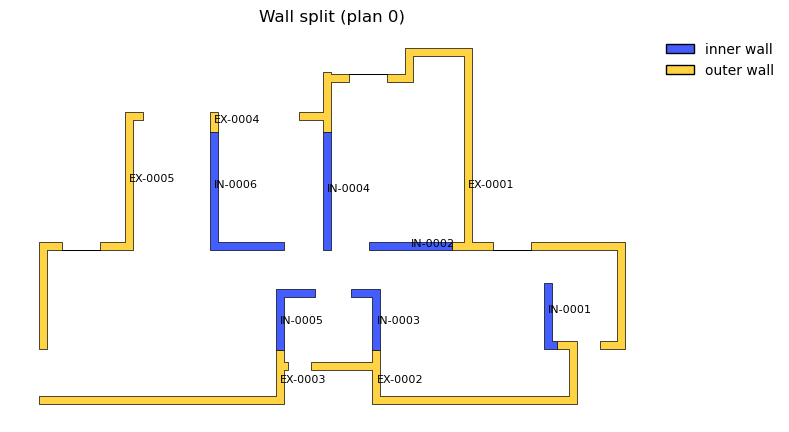

In [15]:
with open(DATA_PKL, "rb") as f:
    plans = pickle.load(f)

idx   = 0
plan  = R.normalize_keys(plans[idx].copy())
print("Total plans:", len(plans), "  sampled idx:", idx)

# export JSON + PNG
json_path = export_one(idx, plan)
print("exported:", json_path)

# quick parity: rooms count in JSON vs approx. from plan
with open(json_path, "r", encoding="utf-8") as f:
    jj = json.load(f)
print("rooms_total (json):", jj["counts"]["rooms_total"])
print("structural counts  :", jj["counts"]["structural"])

# visualize split with instance labels
_ = plot_wall_split_with_labels(plan, title=f"Wall split (plan {idx})")

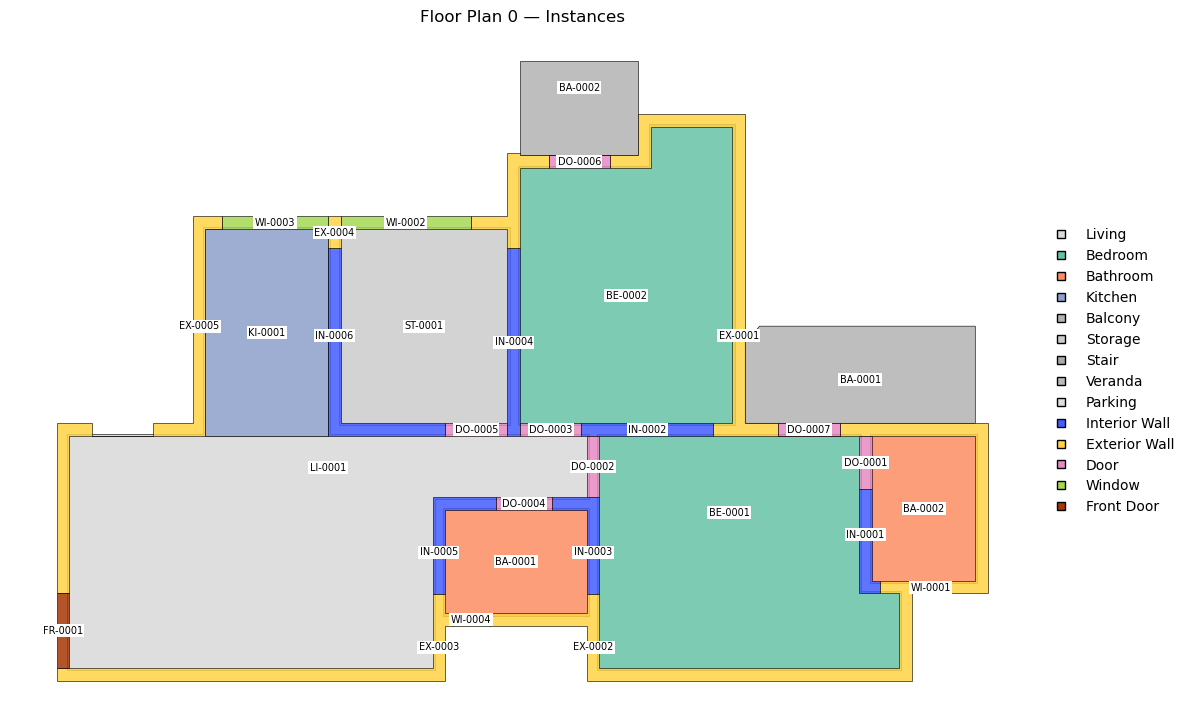

In [16]:
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, Point

def _label_point(g):
    if isinstance(g, (Polygon, MultiPolygon)):
        return g.representative_point()
    if isinstance(g, (LineString, MultiLineString)):
        return g.interpolate(0.5, normalized=True)
    return Point(*list(g.coords)[0])

def plot_floor_plan_instances(plan, title=None, show_labels=True, figsize=(12,10)):
    p = R.normalize_keys(plan.copy())
    rooms  = extract_room_instances(p)
    struct = split_walls(p)

    geoms, colors = [], []
    labels = []

    # rooms
    for cat, insts in rooms.items():
        for it in insts:
            g = shape(it["geom"])
            if g.is_empty: continue
            geoms.append(g); colors.append(ROOM_COLORS.get(cat, "#CCCCCC"))
            labels.append(it["id"])

    # structural
    for cat, insts in struct.items():
        for it in insts:
            g = shape(it["geom"])
            if g.is_empty: continue
            geoms.append(g); colors.append(STRUCT_COLORS.get(cat, "#999999"))
            labels.append(it["id"])

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal"); ax.set_axis_off()
    ax.set_title(title or "Instances")

    # draw
    for g, c, lab in zip(geoms, colors, labels):
        x,y = g.exterior.xy
        ax.fill(x, y, facecolor=c, edgecolor="black", linewidth=0.5, alpha=0.85)
        if show_labels:
            # AFTER (use _label_point if you added it; otherwise keep representative_point)
            rp = _label_point(g)  # or: g.representative_point()
            ax.text(
                rp.x, rp.y, lab,
                fontsize=7, ha="center", va="center", zorder=5, clip_on=True,
                bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="none", alpha=1)
            )

    # legend
    room_handles  = [plt.Line2D([0],[0], marker='s', color='none', markerfacecolor=ROOM_COLORS[k],
                                markeredgecolor="black", label=k.title()) for k in ROOM_COLORS]
    struct_handles= [plt.Line2D([0],[0], marker='s', color='none', markerfacecolor=STRUCT_COLORS[k],
                                markeredgecolor="black", label=k.replace('_',' ').title()) for k in STRUCT_COLORS]
    ax.legend(handles=room_handles+struct_handles, loc='center left', bbox_to_anchor=(1,0.5), frameon=False)
    plt.tight_layout(); plt.show()
    return ax


# example
_ = plot_floor_plan_instances(plan, title=f"Floor Plan {idx} — Instances")